# Predicting the Winning Football Team

- Sports betting is a 500 billion dollar market (Sydney Herald)

- Football is played by 250 million players in over 200 countries (most popular sport globally).
- The English Premier League is the most popular domestic team in the world.
- Design a predictive model capable of accurately predicting if the home team will win a football match? 


**Discription of Dataset**

**A prediction system was built to predict whether a home team will win it's match or not.**

Key to results data:
* Div = League Division
* Date = Match Date (dd/mm/yy)
* Time = Time of match kick-off
* HomeTeam = Home Team
* Away team = Away Team
* FTHG and HG = Full Time Home Team Goals
* FTAG and AG = Full-Time Away Team Goals
* FTR and Res = Full-Time Result (H=Home Win, D=Draw, A=Away Win)
* HTHG = Half Time Home Team Goals
* HTAG = Half Time Away Team Goals
* HTR = Half Time Result (H=Home Win, D=Draw, A=Away Win)

Match Statistics (where available)
* Attendance = Crowd Attendance
* Referee = Match Referee
* HS = Home Team Shots
* AS = Away Team Shots
* HST = Home Team Shots on Target
* AST = Away Team Shots on Target
* HHW = Home Team Hit Woodwork
* AHW = Away Team Hit Woodwork
* HC = Home Team Corners
* AC = Away Team Corners
* HF = Home Team Fouls Committed
* AF = Away Team Fouls Committed
* HFKC = Home Team Free Kicks Conceded
* AFKC = Away Team Free Kicks Conceded
* HO = Home Team Offsides
* AO = Away Team Offsides
* HY = Home Team Yellow Cards
* AY = Away Team Yellow Cards
*HR = Home Team Red Cards
AR = Away Team Red Cards
HBP = Home Team Bookings Points (10 = yellow, 25 = red)
ABP = Away Team Bookings Points (10 = yellow, 25 = red)

### Importing the dataset

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime as dt
import itertools
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

In [51]:
# Read data from the CSV into a dataframe
# Read data from the CSV into a dataframe

# Read data from the CSV into a dataframe

import pandas as pd

raw_data_1 = pd.read_csv('2020-2021.csv')
raw_data_2 = pd.read_csv('2021-2022.csv')

print("Datasets loaded successfully")

raw_data_1.head()


Datasets loaded successfully


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,12/09/2020,12:30,Fulham,Arsenal,0,3,A,0,1,...,1.84,0.75,2.01,1.89,2.02,1.91,2.13,1.92,2.02,1.87
1,E0,12/09/2020,15:00,Crystal Palace,Southampton,1,0,H,1,0,...,1.70,0.25,1.78,2.13,1.79,2.17,1.85,2.18,1.79,2.12
2,E0,12/09/2020,17:30,Liverpool,Leeds,4,3,H,3,2,...,2.62,-1.50,1.85,2.05,1.85,2.08,1.90,2.16,1.84,2.04
3,E0,12/09/2020,20:00,West Ham,Newcastle,0,2,A,0,0,...,1.92,-0.50,2.03,1.87,2.04,1.88,2.09,1.91,2.02,1.86
4,E0,13/09/2020,14:00,West Brom,Leicester,0,3,A,0,0,...,1.73,0.25,1.92,1.98,1.93,1.99,1.95,2.01,1.91,1.97


In [52]:
# Gets all the statistics related to gameplay

columns_req = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']

playing_statistics_1 = raw_data_1[columns_req]
playing_statistics_2 = raw_data_2[columns_req]

print("Playing statistics extracted successfully")

Playing statistics extracted successfully


**GOALS SCORED AND CONCEDED AT THE END OF MATCHWEEK, ARRANGED BY TEAMS AND MATCHWEEK**

In [53]:
# Gets the goals scored agg arranged by teams and matchweek

def get_goals_scored(playing_stat):

    teams = {}

    for i in playing_stat.groupby('HomeTeam').size().index:
        teams[i] = []

    for i in range(len(playing_stat)):
        HTGS = playing_stat.iloc[i]['FTHG']
        ATGS = playing_stat.iloc[i]['FTAG']

        teams[playing_stat.iloc[i].HomeTeam].append(HTGS)
        teams[playing_stat.iloc[i].AwayTeam].append(ATGS)

    GoalsScored = pd.DataFrame(data=teams, index=[i for i in range(1,39)]).T

    GoalsScored[0] = 0

    for i in range(2,39):
        GoalsScored[i] = GoalsScored[i] + GoalsScored[i-1]

    return GoalsScored


# Gets the goals conceded agg arranged by teams and matchweek

def get_goals_conceded(playing_stat):

    teams = {}

    for i in playing_stat.groupby('HomeTeam').size().index:
        teams[i] = []

    for i in range(len(playing_stat)):
        ATGC = playing_stat.iloc[i]['FTHG']
        HTGC = playing_stat.iloc[i]['FTAG']

        teams[playing_stat.iloc[i].HomeTeam].append(HTGC)
        teams[playing_stat.iloc[i].AwayTeam].append(ATGC)

    GoalsConceded = pd.DataFrame(data=teams, index=[i for i in range(1,39)]).T

    GoalsConceded[0] = 0

    for i in range(2,39):
        GoalsConceded[i] = GoalsConceded[i] + GoalsConceded[i-1]

    return GoalsConceded


def get_gss(playing_stat):

    GC = get_goals_conceded(playing_stat)
    GS = get_goals_scored(playing_stat)

    j = 0

    HTGS = []
    ATGS = []
    HTGC = []
    ATGC = []

    for i in range(len(playing_stat)):

        ht = playing_stat.iloc[i].HomeTeam
        at = playing_stat.iloc[i].AwayTeam

        HTGS.append(GS.loc[ht][j])
        ATGS.append(GS.loc[at][j])

        HTGC.append(GC.loc[ht][j])
        ATGC.append(GC.loc[at][j])

        if ((i + 1) % 10) == 0:
            j = j + 1

    playing_stat['HTGS'] = HTGS
    playing_stat['ATGS'] = ATGS
    playing_stat['HTGC'] = HTGC
    playing_stat['ATGC'] = ATGC

    return playing_stat


# Apply only to available datasets

playing_statistics_1 = get_gss(playing_statistics_1)
playing_statistics_2 = get_gss(playing_statistics_2)

print("Goal statistics added successfully")

Goal statistics added successfully


**GET RESPECTIVE POINTS**

In [54]:
def get_points(result):

    if result == 'W':
        return 3

    elif result == 'D':
        return 1

    else:
        return 0


def get_cuml_points(matchres):

    matchres_points = matchres.apply(
        lambda col: col.map(get_points)
    )

    for i in range(2,39):

        matchres_points[i] = (
            matchres_points[i] +
            matchres_points[i-1]
        )

    matchres_points.insert(
        column=0,
        loc=0,
        value=[0*i for i in range(len(matchres_points))]
    )

    return matchres_points


def get_matchres(playing_stat):

    teams = {}

    # FIXED FOR NEW PANDAS
    for i in playing_stat.groupby('HomeTeam').size().index:
        teams[i] = []

    for i in range(len(playing_stat)):

        if playing_stat.iloc[i].FTR == 'H':

            teams[
                playing_stat.iloc[i].HomeTeam
            ].append('W')

            teams[
                playing_stat.iloc[i].AwayTeam
            ].append('L')

        elif playing_stat.iloc[i].FTR == 'A':

            teams[
                playing_stat.iloc[i].AwayTeam
            ].append('W')

            teams[
                playing_stat.iloc[i].HomeTeam
            ].append('L')

        else:

            teams[
                playing_stat.iloc[i].AwayTeam
            ].append('D')

            teams[
                playing_stat.iloc[i].HomeTeam
            ].append('D')

    return pd.DataFrame(
        data=teams,
        index=[i for i in range(1,39)]
    ).T


def get_agg_points(playing_stat):

    matchres = get_matchres(playing_stat)

    cum_pts = get_cuml_points(matchres)

    HTP = []
    ATP = []

    j = 0

    for i in range(len(playing_stat)):

        ht = playing_stat.iloc[i].HomeTeam
        at = playing_stat.iloc[i].AwayTeam

        HTP.append(cum_pts.loc[ht][j])
        ATP.append(cum_pts.loc[at][j])

        if ((i + 1) % 10) == 0:
            j = j + 1

    playing_stat['HTP'] = HTP
    playing_stat['ATP'] = ATP

    return playing_stat


# Apply ONLY to available datasets

playing_statistics_1 = get_agg_points(
    playing_statistics_1
)

playing_statistics_2 = get_agg_points(
    playing_statistics_2
)

print("Aggregate points added successfully")

Aggregate points added successfully


**GET TEAM FORM:**

In [55]:
def get_form(playing_stat, num):

    form = get_matchres(playing_stat)

    form_final = form.copy()

    for i in range(num, 39):

        form_final[i] = ''

        j = 0

        while j < num:

            form_final[i] += form[i-j]

            j += 1

    return form_final


def add_form(playing_stat, num):

    form = get_form(playing_stat, num)

    h = ['M' for i in range(num * 10)]
    a = ['M' for i in range(num * 10)]

    j = num

    for i in range((num * 10), len(playing_stat)):

        ht = playing_stat.iloc[i].HomeTeam
        at = playing_stat.iloc[i].AwayTeam

        past = form.loc[ht][j]
        h.append(past[num - 1])

        past = form.loc[at][j]
        a.append(past[num - 1])

        if ((i + 1) % 10) == 0:
            j = j + 1

    playing_stat['HM' + str(num)] = h
    playing_stat['AM' + str(num)] = a

    return playing_stat


def add_form_df(playing_statistics):

    playing_statistics = add_form(
        playing_statistics, 1
    )

    playing_statistics = add_form(
        playing_statistics, 2
    )

    playing_statistics = add_form(
        playing_statistics, 3
    )

    playing_statistics = add_form(
        playing_statistics, 4
    )

    playing_statistics = add_form(
        playing_statistics, 5
    )

    return playing_statistics


# Apply ONLY to available datasets

playing_statistics_1 = add_form_df(
    playing_statistics_1
)

playing_statistics_2 = add_form_df(
    playing_statistics_2
)

print("Form features added successfully")

Form features added successfully


In [56]:
# Rearranging columns

cols = [
    'Date',
    'HomeTeam',
    'AwayTeam',
    'FTHG',
    'FTAG',
    'FTR',
    'HTGS',
    'ATGS',
    'HTGC',
    'ATGC',
    'HTP',
    'ATP',
    'HM1',
    'HM2',
    'HM3',
    'HM4',
    'HM5',
    'AM1',
    'AM2',
    'AM3',
    'AM4',
    'AM5'
]

playing_statistics_1 = playing_statistics_1[cols]

playing_statistics_2 = playing_statistics_2[cols]

print("Columns rearranged successfully")

Columns rearranged successfully


**Get MatchWeek:**

In [57]:
def get_mw(playing_stat):

    j = 1

    MatchWeek = []

    for i in range(len(playing_stat)):

        MatchWeek.append(j)

        if ((i + 1) % 10) == 0:
            j = j + 1

    playing_stat['MW'] = MatchWeek

    return playing_stat


# Apply ONLY to available datasets

playing_statistics_1 = get_mw(
    playing_statistics_1
)

playing_statistics_2 = get_mw(
    playing_statistics_2
)

print("Matchweek column added successfully")

Matchweek column added successfully


**FINAL DATAFRAME**

In [58]:
# Combine available datasets

playing_stat = pd.concat(
    [
        playing_statistics_1,
        playing_statistics_2
    ],
    ignore_index=True
)


# Gets the form points

def get_form_points(string):

    total = 0

    for letter in string:
        total += get_points(letter)

    return total


playing_stat['HTFormPtsStr'] = (
    playing_stat['HM1'] +
    playing_stat['HM2'] +
    playing_stat['HM3'] +
    playing_stat['HM4'] +
    playing_stat['HM5']
)

playing_stat['ATFormPtsStr'] = (
    playing_stat['AM1'] +
    playing_stat['AM2'] +
    playing_stat['AM3'] +
    playing_stat['AM4'] +
    playing_stat['AM5']
)


playing_stat['HTFormPts'] = (
    playing_stat['HTFormPtsStr']
    .apply(get_form_points)
)

playing_stat['ATFormPts'] = (
    playing_stat['ATFormPtsStr']
    .apply(get_form_points)
)


# Identify Win/Loss streaks

def get_3game_ws(string):

    if string[-3:] == 'WWW':
        return 1

    else:
        return 0


def get_5game_ws(string):

    if string == 'WWWWW':
        return 1

    else:
        return 0


def get_3game_ls(string):

    if string[-3:] == 'LLL':
        return 1

    else:
        return 0


def get_5game_ls(string):

    if string == 'LLLLL':
        return 1

    else:
        return 0


playing_stat['HTWinStreak3'] = (
    playing_stat['HTFormPtsStr']
    .apply(get_3game_ws)
)

playing_stat['HTWinStreak5'] = (
    playing_stat['HTFormPtsStr']
    .apply(get_5game_ws)
)

playing_stat['HTLossStreak3'] = (
    playing_stat['HTFormPtsStr']
    .apply(get_3game_ls)
)

playing_stat['HTLossStreak5'] = (
    playing_stat['HTFormPtsStr']
    .apply(get_5game_ls)
)

playing_stat['ATWinStreak3'] = (
    playing_stat['ATFormPtsStr']
    .apply(get_3game_ws)
)

playing_stat['ATWinStreak5'] = (
    playing_stat['ATFormPtsStr']
    .apply(get_5game_ws)
)

playing_stat['ATLossStreak3'] = (
    playing_stat['ATFormPtsStr']
    .apply(get_3game_ls)
)

playing_stat['ATLossStreak5'] = (
    playing_stat['ATFormPtsStr']
    .apply(get_5game_ls)
)

print("Final combined dataset created successfully")

playing_stat.head()

Final combined dataset created successfully


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HTFormPts,ATFormPts,HTWinStreak3,HTWinStreak5,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5
0,12/09/2020,Fulham,Arsenal,0,3,A,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,12/09/2020,Crystal Palace,Southampton,1,0,H,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,12/09/2020,Liverpool,Leeds,4,3,H,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,12/09/2020,West Ham,Newcastle,0,2,A,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,13/09/2020,West Brom,Leicester,0,3,A,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
# Get Goal Difference
playing_stat['HTGD'] = playing_stat['HTGS'] - playing_stat['HTGC']
playing_stat['ATGD'] = playing_stat['ATGS'] - playing_stat['ATGC']

# Diff in points
playing_stat['DiffPts'] = playing_stat['HTP'] - playing_stat['ATP']
playing_stat['DiffFormPts'] = playing_stat['HTFormPts'] - playing_stat['ATFormPts']

In [60]:
# Scale DiffPts , DiffFormPts, HTGD, ATGD by Matchweek.
cols = ['HTGD','ATGD','DiffPts','DiffFormPts','HTP','ATP']
playing_stat.MW = playing_stat.MW.astype(float)

for col in cols:
    playing_stat[col] = playing_stat[col] / playing_stat.MW

In [61]:
def only_hw(string):
    if string == 'H':
        return 'H'
    else:
        return 'NH'
    
playing_stat['FTR'] = playing_stat.FTR.apply(only_hw)

# Testing set (2015-16 season)
playing_stat_test = playing_stat[5700:]

In [62]:
#saving the final dataset
playing_stat.to_csv('final_dataset.csv')

In [63]:
#saving the test set
playing_stat_test.to_csv("test_set.csv")

In [64]:
#loading the final dataset
dataset = pd.read_csv('final_dataset.csv')

In [65]:
dataset.head()

,Unnamed: 0,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
0,0,12/09/2020,Fulham,Arsenal,0,3,NH,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
1,1,12/09/2020,Crystal Palace,Southampton,1,0,H,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
2,2,12/09/2020,Liverpool,Leeds,4,3,H,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
3,3,12/09/2020,West Ham,Newcastle,0,2,NH,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
4,4,13/09/2020,West Brom,Leicester,0,3,NH,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0


In [66]:
dataset.keys()

Index(['Unnamed: 0', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTGS', 'ATGS', 'HTGC', 'ATGC', 'HTP', 'ATP', 'HM1', 'HM2', 'HM3',
       'HM4', 'HM5', 'AM1', 'AM2', 'AM3', 'AM4', 'AM5', 'MW', 'HTFormPtsStr',
       'ATFormPtsStr', 'HTFormPts', 'ATFormPts', 'HTWinStreak3',
       'HTWinStreak5', 'HTLossStreak3', 'HTLossStreak5', 'ATWinStreak3',
       'ATWinStreak5', 'ATLossStreak3', 'ATLossStreak5', 'HTGD', 'ATGD',
       'DiffPts', 'DiffFormPts'],
      dtype='str')

### Correlation Matrix for dataset

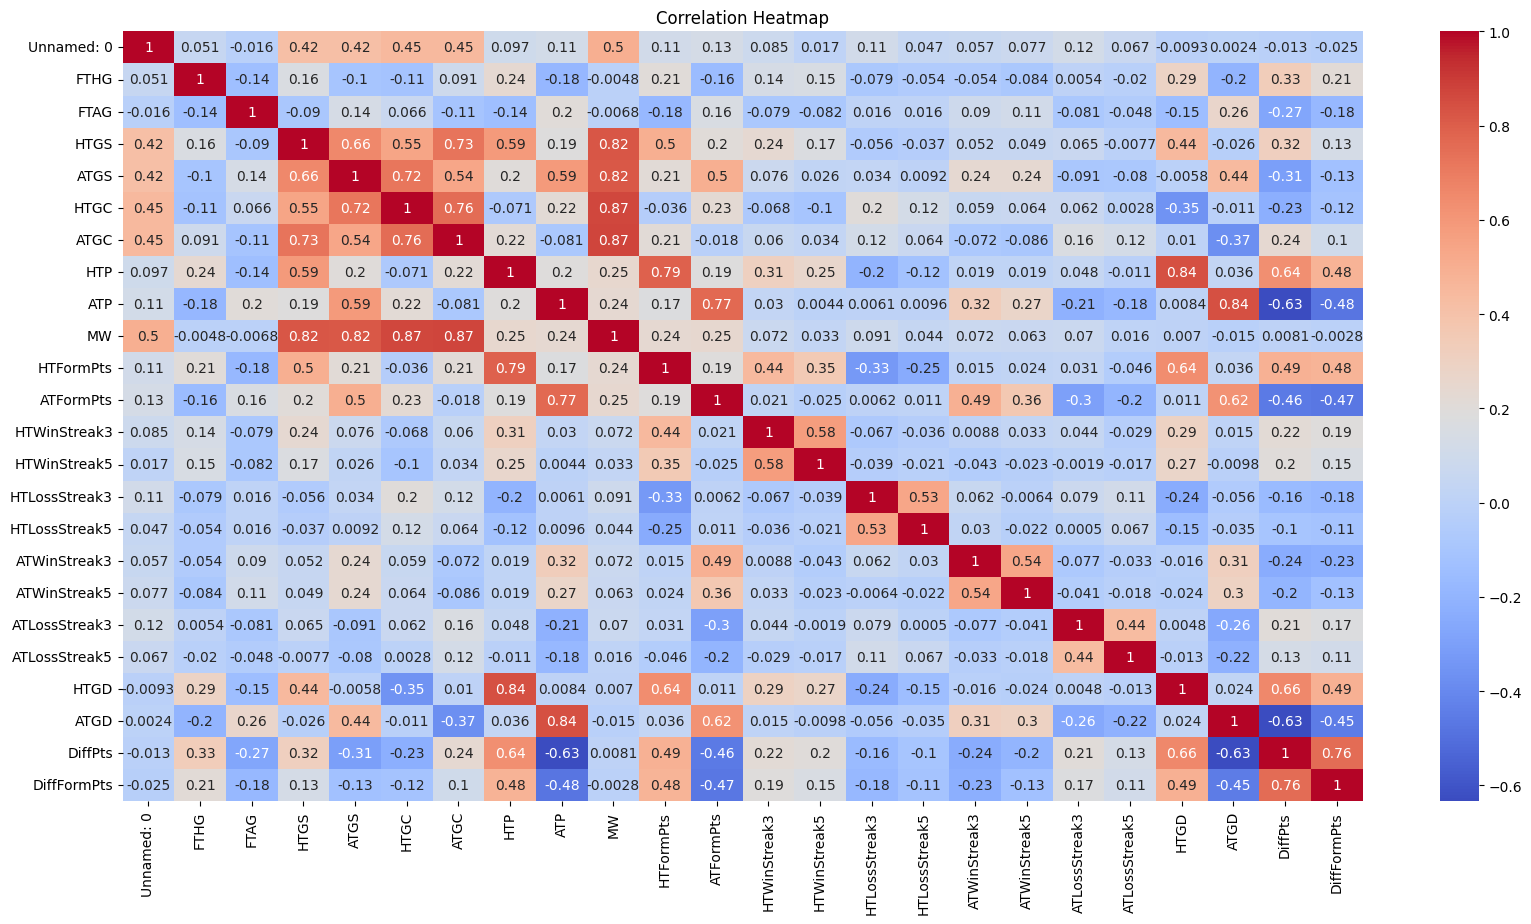

In [67]:
# Correlation Heatmap

plt.figure(figsize=(20,10))

# Select only numeric columns
numeric_dataset = dataset.select_dtypes(
    include=[np.number]
)

sns.heatmap(
    numeric_dataset.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

POSITIVE CORRELATION: If an increase in feature A leads to increase in feature B, then they are positively correlated. A value 1 means perfect positive correlation.

NEGATIVE CORRELATION: If an increase in feature A leads to decrease in feature B, then they are negatively correlated. A value -1 means perfect negative correlation.

Now lets say that two features are highly or perfectly correlated, so the increase in one leads to increase in the other. This means that both the features are containing highly similar information and there is very little or no variance in information. This is known as MultiColinearity as both of them contains almost the same information.

So do you think we should use both of them as one of them is redundant. While making or training models, we should try to eliminate redundant features as it reduces training time and many such advantages.

In [68]:
# Remove few column
dataset2 = dataset.copy().drop(columns =['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG',
       'HTGS', 'ATGS', 'HTGC', 'ATGC',
       'HM4', 'HM5','AM4', 'AM5', 'MW', 'HTFormPtsStr',
       'ATFormPtsStr', 'HTFormPts', 'ATFormPts', 'HTWinStreak3',
       'HTWinStreak5', 'HTLossStreak3', 'HTLossStreak5', 'ATWinStreak3',
       'ATWinStreak5', 'ATLossStreak3', 'ATLossStreak5',
       'DiffPts'] )

In [69]:
dataset2.keys()

Index(['Unnamed: 0', 'FTR', 'HTP', 'ATP', 'HM1', 'HM2', 'HM3', 'AM1', 'AM2',
       'AM3', 'HTGD', 'ATGD', 'DiffFormPts'],
      dtype='str')

In [70]:
dataset2.head(10)

,Unnamed: 0,FTR,HTP,ATP,HM1,HM2,HM3,AM1,AM2,AM3,HTGD,ATGD,DiffFormPts
0,0,NH,0.0,0.0,M,M,M,M,M,M,0.0,0.0,0.0
1,1,H,0.0,0.0,M,M,M,M,M,M,0.0,0.0,0.0
2,2,H,0.0,0.0,M,M,M,M,M,M,0.0,0.0,0.0
3,3,NH,0.0,0.0,M,M,M,M,M,M,0.0,0.0,0.0
4,4,NH,0.0,0.0,M,M,M,M,M,M,0.0,0.0,0.0
5,5,NH,0.0,0.0,M,M,M,M,M,M,0.0,0.0,0.0
6,6,NH,0.0,0.0,M,M,M,M,M,M,0.0,0.0,0.0
7,7,NH,0.0,0.0,M,M,M,M,M,M,0.0,0.0,0.0
8,8,H,0.0,0.0,M,M,M,M,M,M,0.0,0.0,0.0
9,9,H,0.0,0.0,M,M,M,M,M,M,0.0,0.0,0.0


In [71]:
#what is the win rate for the home team?

# Total number of matches.
n_matches = dataset2.shape[0]

# Calculate number of features. -1 because we are saving one as the target variable (win/lose/draw)
n_features = dataset2.shape[1] - 1

# Calculate matches won by home team.
n_homewins = len(dataset2[dataset2.FTR == 'H'])

# Calculate win rate for home team.
win_rate = (float(n_homewins) / (n_matches)) * 100

# Print the results
print("Total number of matches: {}".format(n_matches))
print ("Number of features: {}".format(n_features))
print( "Number of matches won by home team: {}".format(n_homewins))
print ("Win rate of home team: {:.2f}%".format(win_rate))

Total number of matches: 760
Number of features: 12
Number of matches won by home team: 307
Win rate of home team: 40.39%


## Visualise the dataset

array([[<Axes: xlabel='HTGD', ylabel='HTGD'>,
        <Axes: xlabel='ATGD', ylabel='HTGD'>,
        <Axes: xlabel='HTP', ylabel='HTGD'>,
        <Axes: xlabel='ATP', ylabel='HTGD'>,
        <Axes: xlabel='DiffFormPts', ylabel='HTGD'>],
       [<Axes: xlabel='HTGD', ylabel='ATGD'>,
        <Axes: xlabel='ATGD', ylabel='ATGD'>,
        <Axes: xlabel='HTP', ylabel='ATGD'>,
        <Axes: xlabel='ATP', ylabel='ATGD'>,
        <Axes: xlabel='DiffFormPts', ylabel='ATGD'>],
       [<Axes: xlabel='HTGD', ylabel='HTP'>,
        <Axes: xlabel='ATGD', ylabel='HTP'>,
        <Axes: xlabel='HTP', ylabel='HTP'>,
        <Axes: xlabel='ATP', ylabel='HTP'>,
        <Axes: xlabel='DiffFormPts', ylabel='HTP'>],
       [<Axes: xlabel='HTGD', ylabel='ATP'>,
        <Axes: xlabel='ATGD', ylabel='ATP'>,
        <Axes: xlabel='HTP', ylabel='ATP'>,
        <Axes: xlabel='ATP', ylabel='ATP'>,
        <Axes: xlabel='DiffFormPts', ylabel='ATP'>],
       [<Axes: xlabel='HTGD', ylabel='DiffFormPts'>,
        <Axes

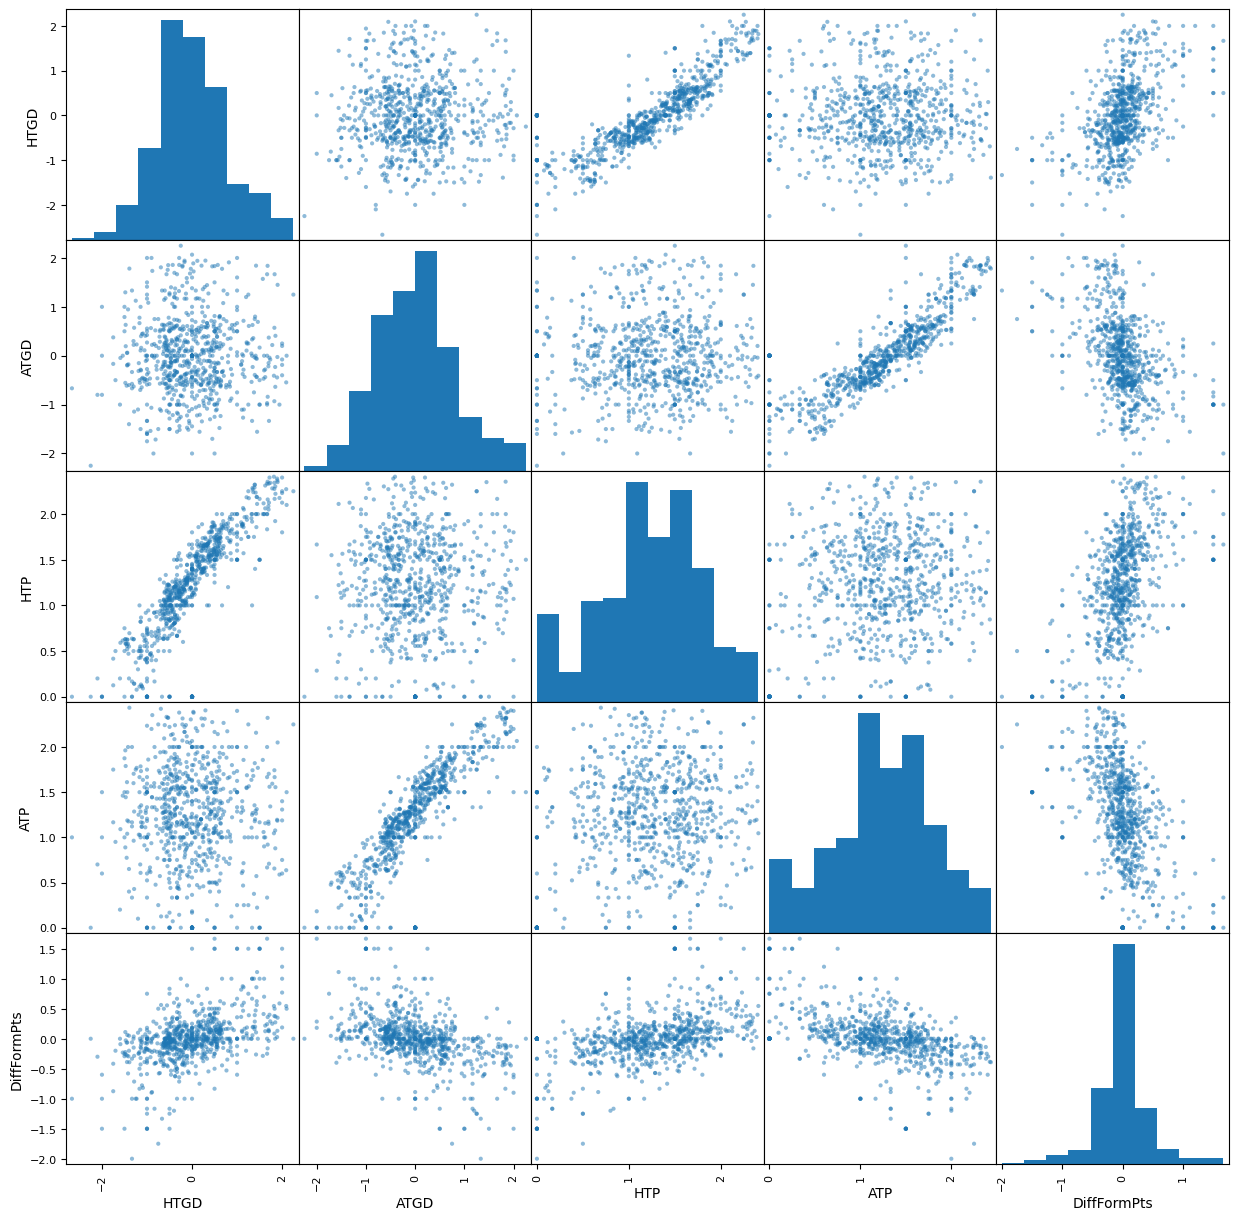

In [72]:
# Visualising distribution of data
from pandas.plotting import scatter_matrix

#the scatter matrix is plotting each of the columns specified against each other column.
#You would have observed that the diagonal graph is defined as a histogram, which means that in the 
#section of the plot matrix where the variable is against itself, a histogram is plotted.

#Scatter plots show how much one variable is affected by another. 
#The relationship between two variables is called their correlation
#negative vs positive correlation

#HTGD - Home team goal difference
#ATGD - away team goal difference
#HTP - Home team points
#ATP - Away team points
#DiffFormPts Diff in points
#DiffLP - Differnece in last years prediction

scatter_matrix(dataset2[['HTGD','ATGD','HTP','ATP','DiffFormPts']], figsize=(15,15))

In [73]:
# Separate into feature set and target variable

# FTR = Full Time Result
# H = Home Win
# D = Draw
# A = Away Win

X_all = dataset2.drop(columns=['FTR'])

y_all = dataset2['FTR']


# Standardising the data

from sklearn.preprocessing import scale

cols = ['HTGD', 'ATGD', 'HTP', 'ATP']

X_all[cols] = scale(X_all[cols])

print("Features and target prepared successfully")

X_all.head()

Features and target prepared successfully


,Unnamed: 0,HTP,ATP,HM1,HM2,HM3,AM1,AM2,AM3,HTGD,ATGD,DiffFormPts
0,0,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
1,1,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
2,2,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
3,3,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
4,4,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0


In [74]:
# Convert recent match columns to string

X_all['HM1'] = X_all['HM1'].astype(str)
X_all['HM2'] = X_all['HM2'].astype(str)
X_all['HM3'] = X_all['HM3'].astype(str)

X_all['AM1'] = X_all['AM1'].astype(str)
X_all['AM2'] = X_all['AM2'].astype(str)
X_all['AM3'] = X_all['AM3'].astype(str)


# Preprocess features

def preprocess_features(X):

    output = pd.DataFrame(index=X.index)

    for col in X.columns:

        col_data = X[col]

        # Convert categorical columns into dummy variables

        if col_data.dtype == object:

            col_data = pd.get_dummies(
                col_data,
                prefix=col
            )

        output = output.join(col_data)

    return output


# Apply preprocessing

X_all = preprocess_features(X_all)

print(
    "Processed feature columns ({} total features):".format(
        len(X_all.columns)
    )
)

print(X_all.columns)

X_all.head()

Processed feature columns (12 total features):
Index(['Unnamed: 0', 'HTP', 'ATP', 'HM1', 'HM2', 'HM3', 'AM1', 'AM2', 'AM3',
       'HTGD', 'ATGD', 'DiffFormPts'],
      dtype='str')


,Unnamed: 0,HTP,ATP,HM1,HM2,HM3,AM1,AM2,AM3,HTGD,ATGD,DiffFormPts
0,0,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
1,1,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
2,2,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
3,3,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
4,4,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0


In [75]:
X_all.head(10)

,Unnamed: 0,HTP,ATP,HM1,HM2,HM3,AM1,AM2,AM3,HTGD,ATGD,DiffFormPts
0,0,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
1,1,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
2,2,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
3,3,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
4,4,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
5,5,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
6,6,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
7,7,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
8,8,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0
9,9,-2.175309,-2.191654,M,M,M,M,M,M,0.003617,-0.008316,0.0


In [76]:
y_all

0      NH
1       H
2       H
3      NH
4      NH
       ..
755     H
756     H
757     H
758     H
759    NH
Name: FTR, Length: 760, dtype: str

## Spliting the dataset

In [77]:
from sklearn.model_selection import train_test_split

# Shuffle and split the dataset into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, 
                                                    test_size = 0.3,
                                                    random_state = 2,
                                                    stratify = y_all)

# Applying the Logistic Regression

In [78]:
# Convert all remaining categorical columns into numbers

X_all = pd.get_dummies(X_all)

# Split dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42
)

print("Dataset prepared successfully")

print(X_train.shape)
print(X_test.shape)

Dataset prepared successfully
(608, 30)
(152, 30)


In [79]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(
    random_state=0,
    max_iter=1000
)

classifier.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [80]:
Y_pred = classifier.predict(X_test)

In [81]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, Y_pred)

<Axes: >

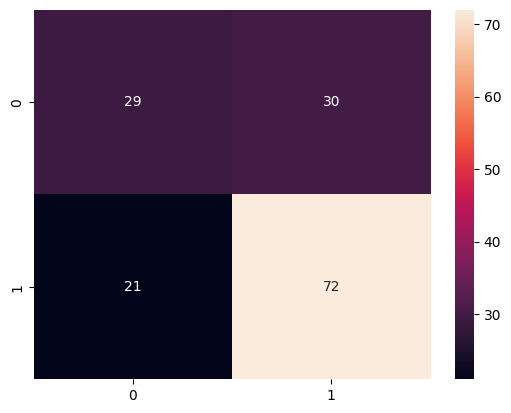

In [82]:
sns.heatmap(cm, annot=True,fmt='d')

In [83]:
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           H       0.58      0.49      0.53        59
          NH       0.71      0.77      0.74        93

    accuracy                           0.66       152
   macro avg       0.64      0.63      0.64       152
weighted avg       0.66      0.66      0.66       152



# Applying the SVM

In [85]:
#fitting the SVM to the training set
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf',random_state = 0)
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [86]:
#predicting result
Y_pred = classifier.predict(X_test)

In [87]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, Y_pred)

<Axes: >

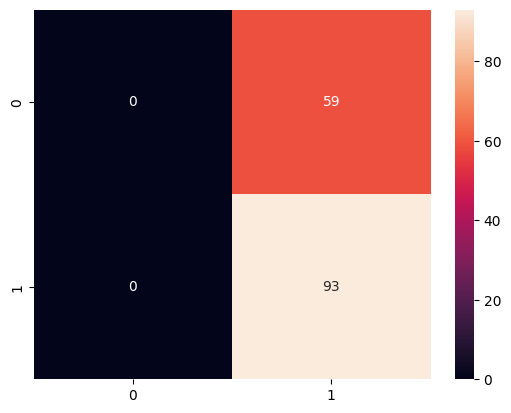

In [88]:
sns.heatmap(cm, annot=True, fmt='d')

In [89]:
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           H       0.00      0.00      0.00        59
          NH       0.61      1.00      0.76        93

    accuracy                           0.61       152
   macro avg       0.31      0.50      0.38       152
weighted avg       0.37      0.61      0.46       152



# Applying the RandomForest

In [91]:
# Fitting Random Forest to the Training set

from sklearn.ensemble import RandomForestClassifier


classifier = RandomForestClassifier(

    criterion='gini',

    n_estimators=700,

    min_samples_split=10,

    min_samples_leaf=1,

    max_features='sqrt',

    oob_score=True,

    random_state=1,

    n_jobs=-1
)


classifier.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [92]:
y_train

693     H
361    NH
266    NH
90      H
368    NH
       ..
71      H
106    NH
270    NH
435    NH
102    NH
Name: FTR, Length: 608, dtype: str

In [93]:
#predicting result
Y_pred = classifier.predict(X_test)

In [94]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, Y_pred)

<Axes: >

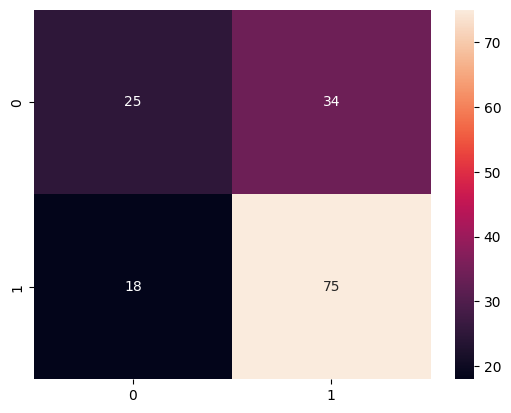

In [95]:
sns.heatmap(cm, annot=True, fmt='d')

In [96]:
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           H       0.58      0.42      0.49        59
          NH       0.69      0.81      0.74        93

    accuracy                           0.66       152
   macro avg       0.63      0.62      0.62       152
weighted avg       0.65      0.66      0.64       152



# Applying the XGBoost

In [98]:
# Fitting XGBoost to the Training set

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder


# Encode target labels

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_test_encoded = label_encoder.transform(
    y_test
)


# Create model

classifier = XGBClassifier(

    random_state=82,

    eval_metric='mlogloss',

    n_estimators=200,

    max_depth=5,

    learning_rate=0.1
)


# Train model

classifier.fit(
    X_train,
    y_train_encoded
)

print("XGBoost model trained successfully")

XGBoost model trained successfully


In [99]:
# Predicting the Test set results
Y_pred = classifier.predict(X_test)

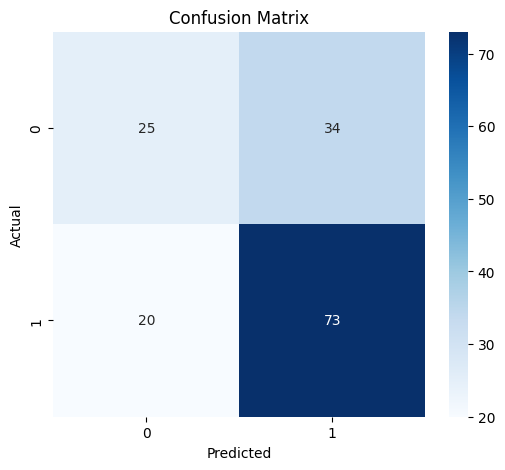

Confusion Matrix Generated Successfully


In [101]:
# Make Predictions

Y_pred_encoded = classifier.predict(X_test)

# Convert predictions back to original labels

Y_pred = label_encoder.inverse_transform(
    Y_pred_encoded
)


# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_test,
    Y_pred
)


# Plot confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


print("Confusion Matrix Generated Successfully")

<Axes: >

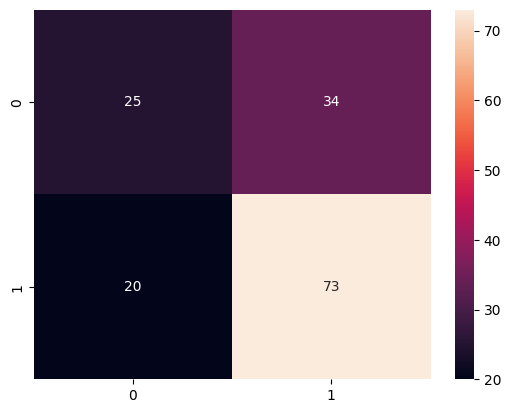

In [102]:
sns.heatmap(cm, annot=True,fmt='d')

In [103]:
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           H       0.56      0.42      0.48        59
          NH       0.68      0.78      0.73        93

    accuracy                           0.64       152
   macro avg       0.62      0.60      0.61       152
weighted avg       0.63      0.64      0.63       152



**Clearly XGBoost seems like the best model as it has the highest F1 score and accuracy score on the test set.**

# Tuning the parameters of XGBoost.


In [105]:
# GridSearchCV for XGBoost

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    make_scorer,
    f1_score,
    accuracy_score
)

from sklearn.preprocessing import LabelEncoder

import xgboost as xgb


# Encode target labels

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_test_encoded = label_encoder.transform(
    y_test
)


# Parameters to tune

parameters = {

    'learning_rate': [0.1],

    'n_estimators': [40],

    'max_depth': [3],

    'min_child_weight': [3],

    'gamma': [0.4],

    'subsample': [0.8],

    'colsample_bytree': [0.8],

    'reg_alpha': [1e-5]
}


# Prediction evaluation function

def predict_labels(clf, features, target):

    y_pred_encoded = clf.predict(features)

    y_pred = label_encoder.inverse_transform(
        y_pred_encoded
    )

    target_original = label_encoder.inverse_transform(
        target
    )

    f1 = f1_score(
        target_original,
        y_pred,
        average='weighted'
    )

    acc = accuracy_score(
        target_original,
        y_pred
    )

    return f1, acc


# Initialize classifier

clf = xgb.XGBClassifier(

    random_state=2,

    eval_metric='mlogloss'
)


# Create scorer

f1_scorer = make_scorer(
    f1_score,
    average='weighted'
)


# Grid Search

grid_obj = GridSearchCV(

    estimator=clf,

    param_grid=parameters,

    scoring=f1_scorer,

    cv=5,

    n_jobs=-1
)


# Fit GridSearch

grid_obj.fit(
    X_train,
    y_train_encoded
)


# Best estimator

clf = grid_obj.best_estimator_

print("Best Model:")

print(clf)


# Training performance

f1, acc = predict_labels(
    clf,
    X_train,
    y_train_encoded
)

print(
    "Training Set -> F1 Score: {:.4f}, Accuracy: {:.4f}"
    .format(f1, acc)
)


# Testing performance

f1, acc = predict_labels(
    clf,
    X_test,
    y_test_encoded
)

print(
    "Test Set -> F1 Score: {:.4f}, Accuracy: {:.4f}"
    .format(f1, acc)
)

Best Model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.4,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=40, n_jobs=None,
              num_parallel_tree=None, ...)
Training Set -> F1 Score: 0.7804, Accuracy: 0.7845
Test Set -> F1 Score: 0.6117, Accuracy: 0.6250


#### Probably little best!!!!!!!!

Accuracy is not soo good but it can improved.

Actually it only depend upon past year match dataset,we can improve the accuracy by putting twitter data related to match, sentiment analysis, chances of player to play a specific match,player performace in recent series,etc..

I hope you find this kernel useful and enjoyable. If so please upVote

Your comments and feedback are most welcome.